# Comparação dos resíduos e Ljung-Box

**Etapa:** diagnóstico conjunto dos quatro modelos

Os p-valores do Ljung-Box são comparados nos lags 1 a 20 e combinados com estatísticas descritivas dos resíduos.

**Entrada:** ljung_box.csv e previsões congeladas  
**Resultado principal:** Holt-Winters e PLS sem rejeições; SARIMAX com 1 e RF com 3


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Comparação do Ljung-Box

,model,min_p_value,tested_lags,rejected_lags_5pct,p_value_lag_20,mean_residual,residual_std,median_residual,max_abs_residual,interpretation
0,Holt_Winters,0.101847,20,0,0.404066,0.113135,15.736278,0.906248,66.820821,sem evidência de autocorrelação nos lags 1 a 20
1,PLS_Regression,0.106298,20,0,0.355046,0.233715,15.880724,1.088112,67.543999,sem evidência de autocorrelação nos lags 1 a 20
2,Random_Forest,0.015480,20,3,0.400785,3.161506,20.575651,2.678775,117.316303,há evidência de autocorrelação; interpretar co...
3,SARIMAX,0.040362,20,1,0.316222,0.362117,15.747025,1.311190,65.491651,há evidência de autocorrelação; interpretar co...


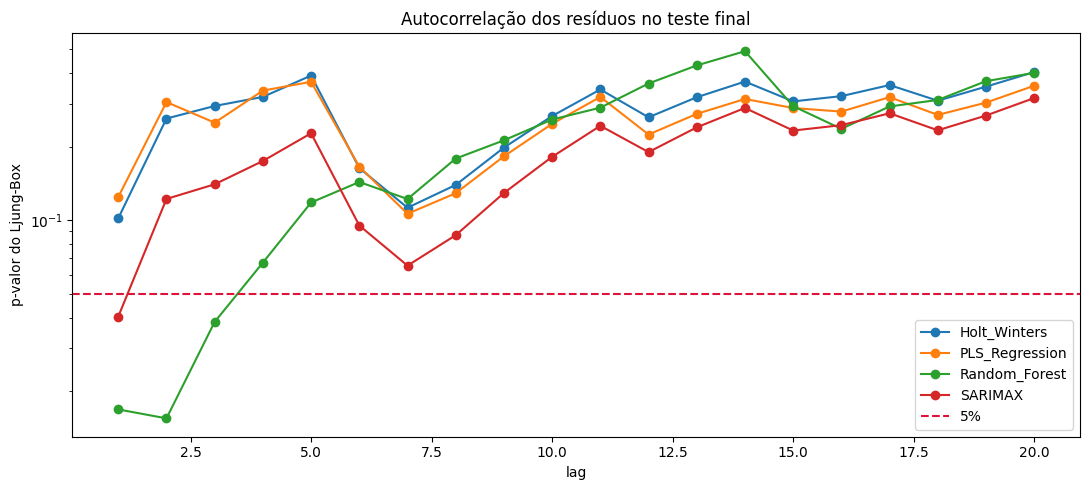

In [3]:
protocol = load_protocol(require_data_decisions=True)
ljung = pd.read_csv(OUT / "ljung_box.csv")
residuals = pd.read_csv(OUT / "residual_summary.csv")

expected = {"SARIMAX", "Holt_Winters", "Random_Forest", "PLS_Regression"}
if set(ljung["model"]) != expected:
    raise RuntimeError("Faltam resultados de Ljung-Box para um ou mais modelos.")

summary = (
    ljung.groupby("model", as_index=False)
    .agg(
        min_p_value=("lb_pvalue", "min"),
        tested_lags=("lag", "max"),
        rejected_lags_5pct=("lb_pvalue", lambda values: int((values < 0.05).sum())),
    )
)
p20 = (
    ljung[ljung["lag"] == 20][["model", "lb_pvalue"]]
    .rename(columns={"lb_pvalue": "p_value_lag_20"})
)
summary = summary.merge(p20, on="model", how="left", validate="one_to_one")
summary = summary.merge(residuals, on="model", how="left", validate="one_to_one")
summary["interpretation"] = np.where(
    summary["rejected_lags_5pct"] == 0,
    "sem evidência de autocorrelação nos lags 1 a 20",
    "há evidência de autocorrelação; interpretar com cautela",
)
summary.to_csv(OUT / "ljung_box_summary.csv", index=False)
display(summary.sort_values("model"))

fig, ax = plt.subplots(figsize=(11, 5))
for model, group in ljung.groupby("model"):
    ax.plot(group["lag"], group["lb_pvalue"], marker="o", label=model)
ax.axhline(0.05, color="crimson", linestyle="--", label="5%")
ax.set_yscale("log")
ax.set_xlabel("lag")
ax.set_ylabel("p-valor do Ljung-Box")
ax.set_title("Autocorrelação dos resíduos no teste final")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "ljung_box_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Diagnóstico residual consolidado

In [4]:
# FINAL_RESIDUAL_DIAGNOSTICS
# Consolidação calculada exclusivamente a partir das previsões congeladas.

predictions = pd.read_csv(OUT / "predictions.csv")
assert np.allclose(predictions["residual"], predictions["y_true"] - predictions["y_pred"])

diagnostics = (
    predictions.groupby("model", as_index=False)
    .agg(
        n_residuos=("residual", "size"),
        media_residuos=("residual", "mean"),
        mediana_residuos=("residual", "median"),
        desvio_padrao_residuos=("residual", "std"),
        minimo_residuo=("residual", "min"),
        maximo_residuo=("residual", "max"),
        mae=("residual", lambda values: values.abs().mean()),
        assimetria=("residual", "skew"),
    )
)

diagnostics = diagnostics.merge(
    summary[[
        "model",
        "min_p_value",
        "tested_lags",
        "rejected_lags_5pct",
        "p_value_lag_20",
    ]],
    on="model",
    how="left",
    validate="one_to_one",
)

def bias_interpretation(row):
    if abs(row["media_residuos"]) <= 0.05 * row["mae"]:
        return "média próxima de zero; sem viés médio relevante"
    if row["media_residuos"] > 0:
        return "viés positivo: subestimação média"
    return "viés negativo: superestimação média"




In [5]:
def autocorrelation_interpretation(rejected_lags):
    if rejected_lags == 0:
        return "sem rejeição nos lags 1 a 20; resíduos compatíveis com ausência de autocorrelação detectável"
    if rejected_lags == 1:
        return "uma rejeição isolada em 20 lags; evidência pontual, sem conclusão ampla"
    return f"{rejected_lags} rejeições em 20 lags; há alguma estrutura remanescente, mas não em todos os lags"


diagnostics["interpretacao_vies"] = diagnostics.apply(bias_interpretation, axis=1)
diagnostics["interpretacao_autocorrelacao"] = diagnostics["rejected_lags_5pct"].map(
    autocorrelation_interpretation
)
diagnostics["padrao_visual_resumido"] = diagnostics["model"].map(
    {
        "Holt_Winters": "dispersão relativamente estável e centrada próxima de zero",
        "SARIMAX": "dispersão semelhante à de Holt-Winters, com evidência pontual no lag 1",
        "PLS_Regression": "dispersão semelhante aos modelos estatísticos e sem rejeições no Ljung-Box",
        "Random_Forest": "maior dispersão, cauda extrema mais ampla e subestimação média",
    }
)

diagnostics.to_csv(OUT / "residual_diagnostics_summary.csv", index=False)
display(diagnostics.sort_values("mae"))

,model,n_residuos,media_residuos,mediana_residuos,desvio_padrao_residuos,minimo_residuo,maximo_residuo,mae,assimetria,min_p_value,tested_lags,rejected_lags_5pct,p_value_lag_20,interpretacao_vies,interpretacao_autocorrelacao,padrao_visual_resumido
0,Holt_Winters,296,0.113135,0.906248,15.736278,-66.820821,62.645552,11.533090,-0.093980,0.101847,20,0,0.404066,média próxima de zero; sem viés médio relevante,sem rejeição nos lags 1 a 20; resíduos compatí...,dispersão relativamente estável e centrada pró...
3,SARIMAX,296,0.362117,1.311190,15.747025,-65.491651,63.588921,11.598841,-0.061740,0.040362,20,1,0.316222,média próxima de zero; sem viés médio relevante,uma rejeição isolada em 20 lags; evidência pon...,"dispersão semelhante à de Holt-Winters, com ev..."
1,PLS_Regression,296,0.233715,1.088112,15.880724,-67.543999,63.432462,11.600212,-0.075656,0.106298,20,0,0.355046,média próxima de zero; sem viés médio relevante,sem rejeição nos lags 1 a 20; resíduos compatí...,dispersão semelhante aos modelos estatísticos ...
2,Random_Forest,296,3.161506,2.678775,20.575651,-88.950899,117.316303,14.282618,0.622582,0.015480,20,3,0.400785,viés positivo: subestimação média,3 rejeições em 20 lags; há alguma estrutura re...,"maior dispersão, cauda extrema mais ampla e su..."


## Interpretação

Holt-Winters apresentou o conjunto mais próximo de ruído, com PLS muito próximo. Rejeições isoladas não sustentam conclusões amplas.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/ljung_box.csv`
- `outputs/ljung_box_summary.csv`
- `outputs/residual_diagnostics_summary.csv`
- `outputs/ljung_box_comparison.png`